# Phase 2A: Affordability Stress as a Mechanism Check


Goal:
Test whether lagged affordability stress (ΔDTI, YoY)
predicts delinquency acceleration in down regimes,
excluding COVID (2020Q4–2022Q2).


### Phase 2A Conclusion

In down-rate regimes (real_rate < 0), lagged affordability stress measured by
ΔDTI does not exhibit a stable lead–lag relationship with subsequent housing
price stress proxies, either in level (YoY) or acceleration terms.

Instead, ΔDTI appears to function as a contemporaneous or state-dependent
risk descriptor rather than a forward-looking timing signal. This finding
reinforces the Phase 1 result that affordability is best interpreted as a
regime-conditional risk filter, particularly useful for identifying late-cycle
fragility rather than predicting turning points.


In [8]:
import os
os.getcwd()


'/Users/axl/Mispricing Model_Leviathan/leviathan-model/notebooks'

In [9]:
df = pd.read_csv("../data/processed/phase1_main.csv")
df.head()

,date,dti,real_rate,regime,real_price_index
0,1999-03-31,83.132765,0.182830,0,100.000000
1,1999-06-30,91.074562,-0.261601,1,100.869636
2,1999-09-30,84.070830,1.153580,0,102.615396
3,1999-12-31,85.778245,1.566901,0,102.076655
4,2000-03-31,88.622364,0.071797,0,102.928067


In [11]:
df["regime"].value_counts(dropna=False)

regime
0    56
1    48
Name: count, dtype: int64

In [12]:
df.groupby("regime")["real_rate"].mean()


regime
0    0.913207
1   -1.111967
Name: real_rate, dtype: float64

In [13]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df["delta_dti_yoy"] = df["dti"] - df["dti"].shift(4)


In [14]:
df["covid_dummy"] = ((df["date"] >= "2020-10-01") & (df["date"] <= "2022-06-30")).astype(int)


In [15]:
DOWN_REGIME = 0  # 你用上面 groupby 的结果来确认
df_main = df[df["covid_dummy"] == 0].copy()
df_down = df_main[df_main["regime"] == DOWN_REGIME].copy()

df_down[["date", "dti", "delta_dti_yoy", "real_rate"]].dropna().head()


,date,dti,delta_dti_yoy,real_rate
4,2000-03-31,88.622364,5.489599,0.071797
5,2000-06-30,83.972544,-7.102018,0.627360
6,2000-09-30,88.781469,4.710639,1.568165
7,2000-12-31,88.873529,3.095285,1.296148
8,2001-03-31,87.695195,-0.927169,1.382213


In [17]:
df["rpi_yoy"] = df["real_price_index"] - df["real_price_index"].shift(4)


In [18]:
df["rpi_yoy_accel"] = df["rpi_yoy"] - df["rpi_yoy"].shift(1)


In [19]:
DOWN_REGIME = 1
df_main = df[df["covid_dummy"] == 0].copy()
df_down = df_main[df_main["regime"] == DOWN_REGIME].copy()


In [21]:
df_down["stress_group"] = np.nan  # 先创建列（object dtype）

df_down.loc[df_down["delta_dti_yoy"] >= hi, "stress_group"] = "High ΔDTI"
df_down.loc[df_down["delta_dti_yoy"] <= lo, "stress_group"] = "Low ΔDTI"

df_plot = df_down.dropna(subset=["stress_group"]).copy()

/var/folders/dg/2kv5bj0j5d9c8wklbylhzg800000gn/T/ipykernel_39344/1429320457.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'High ΔDTI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_down.loc[df_down["delta_dti_yoy"] >= hi, "stress_group"] = "High ΔDTI"


In [23]:
df_plot["stress_group"].value_counts()


stress_group
High ΔDTI    13
Low ΔDTI     13
Name: count, dtype: int64

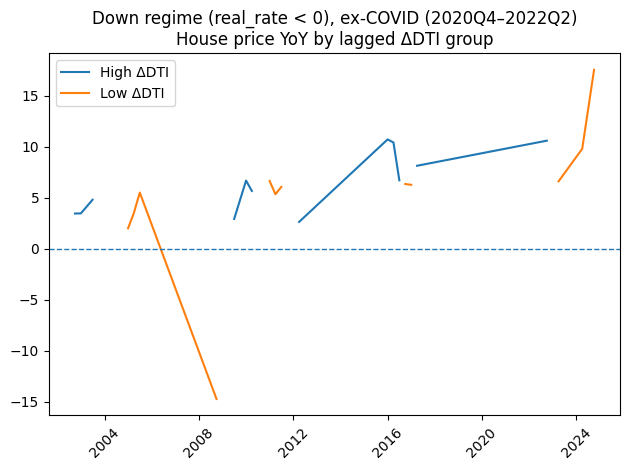

In [24]:
g = (
    df_plot
    .groupby(["date", "stress_group"])["rpi_yoy"]
    .mean()
    .unstack()
)

plt.figure()
plt.plot(g.index, g["High ΔDTI"], label="High ΔDTI")
plt.plot(g.index, g["Low ΔDTI"], label="Low ΔDTI")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title(
    "Down regime (real_rate < 0), ex-COVID (2020Q4–2022Q2)\n"
    "House price YoY by lagged ΔDTI group"
)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


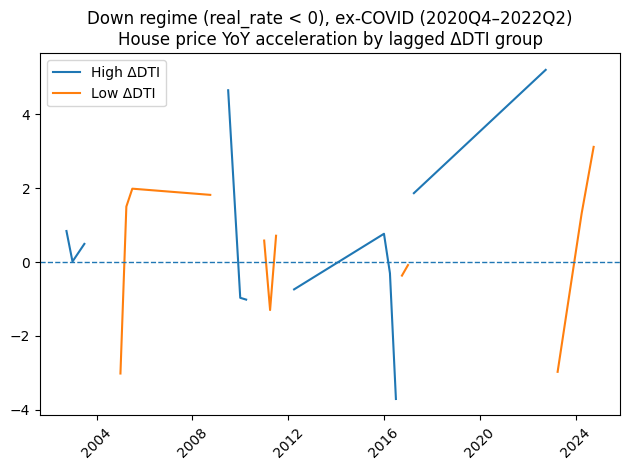

In [25]:
g2 = (
    df_plot
    .groupby(["date", "stress_group"])["rpi_yoy_accel"]
    .mean()
    .unstack()
)

plt.figure()
plt.plot(g2.index, g2["High ΔDTI"], label="High ΔDTI")
plt.plot(g2.index, g2["Low ΔDTI"], label="Low ΔDTI")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title(
    "Down regime (real_rate < 0), ex-COVID (2020Q4–2022Q2)\n"
    "House price YoY acceleration by lagged ΔDTI group"
)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()
